# Hierarchical Forecasting

In our previous lesson, we learned how to build a Global Machine Learning model to forecast thousands of items simultaneously. But in massive enterprise environments like Walmart, Coca-Cola, or Amazon, data does not exist in a flat list. It exists in a strict **Hierarchy**.

You have individual *SKUs* (e.g., a 12-pack of Cherry Cola). Those SKUs roll up into a *Category* (Soda). Categories roll up into a *Store* (Store #402). Stores roll up into a *State* (Texas). States roll up into the *National Total*.

If the CFO asks for the National Revenue forecast, and the Supply Chain Manager asks for the individual SKU forecasts, you face a catastrophic mathematical paradox: **The sum of your individual SKU forecasts will almost never equal your National forecast.** This inconsistency will destroy trust in your AI. To fix this, we must use **Hierarchical Reconciliation**.

Hierarchical Forecasting is the mathematical discipline of ensuring that forecasts generated at different levels of aggregation perfectly align with one another, while minimizing the overall statistical error.

Let's set up our Python environment to architect a perfectly reconciled supply chain.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Hierarchical Reconciliation Environment Ready.")

✅ Hierarchical Reconciliation Environment Ready.


# 1. The Aggregation Paradox

Let's define a simple 2-level hierarchy:

* $y_{Total}$: Total National Sales
* $y_A$: Sales in Region A
* $y_B$: Sales in Region B

By definition, the actual historical data perfectly sums:


$$y_{Total, t} = y_{A, t} + y_{B, t}$$

If we train three separate, independent forecasting models (one for National, one for A, one for B), we generate **Base Forecasts** ($\hat{y}$). Because each model learns different statistical noise, the Base Forecasts will violate the laws of physics:


$$\hat{y}_{Total, t+1} \neq \hat{y}_{A, t+1} + \hat{y}_{B, t+1}$$

If you hand these numbers to a business, the accounting department will reject the model immediately. We must mathematically force them to equal each other.

# 2. Traditional Reconciliation Strategies

Historically, Data Scientists solved this by only forecasting one level, and forcing the other levels to obey.

### 1. Bottom-Up (The Supply Chain Approach)

You only train models at the very bottom level (Region A and Region B). To get the National forecast, you simply add them together.

* **Pros**: No information is lost. You capture the microscopic nuances of every region.
* **Cons**: Low-level data is incredibly noisy. If a local model makes a massive error, that error rolls up and violently corrupts the National total.

### 2. Top-Down (The Executive Approach)

You only train one model at the very top (National). To get the regional forecasts, you mathematically distribute the National number downwards based on historical proportions (e.g., "Region A usually accounts for $60\%$ of total sales").

* **Pros**: The National forecast is highly stable and accurate because aggregated data is very smooth.
* **Cons**: It assumes history never changes. If Region B suddenly starts growing faster than Region A, the Top-Down proportions will completely fail to capture the microscopic shift.

### 3. Middle-Out

You forecast a middle layer (e.g., State). You aggregate the State forecasts *up* to get the National total (Bottom-Up), and you distribute the State forecasts *down* to get the individual Store totals (Top-Down).

# 3. Optimal Reconciliation: The MinT Algorithm

In 2018, statisticians discovered the mathematical holy grail of hierarchical forecasting: **Minimum Trace (MinT) Optimal Reconciliation**.

Instead of choosing one level, MinT trains a model for *every single node in the hierarchy* to generate independent Base Forecasts. Then, it uses a massive Linear Algebra projection matrix to subtly adjust every single forecast simultaneously.

It calculates the covariance matrix of the model errors ($W$). It shifts the National forecast slightly down, and the Regional forecasts slightly up, finding the exact mathematical middle ground that perfectly balances the hierarchy while **minimizing the overall variance of the entire system**.

The reconciled forecast $\tilde{y}$ is calculated using the Summing Matrix ($S$) and the Projection Matrix ($P$):


$$\tilde{y}_{t+h} = S P \hat{y}_{t+h}$$

# 4. Hierarchical Forecasting in Code

Let's simulate a National business with two regions. We will inject a massive, universal exogenous shock (**New Year's Day**) into the data. We will generate Base Forecasts that fail to add up, and then manually apply a Bottom-Up and a Top-Down reconciliation to fix the math.

*(Note: In an enterprise environment, you would use a specialized library like `HierarchicalForecast` by Nixtla to run the complex MinT linear algebra).*

--- 🚨 THE AGGREGATION PARADOX 🚨 ---
Base National Forecast:    515.0
Sum of Base Regional (A+B): 500.0
Discrepancy (Error):        15.0

--- ✅ BOTTOM-UP RECONCILIATION ---
National: 500.0  |  Region A: 355.0  |  Region B: 145.0

--- ✅ TOP-DOWN RECONCILIATION ---
National: 515.0  |  Region A: 352.1  |  Region B: 162.9


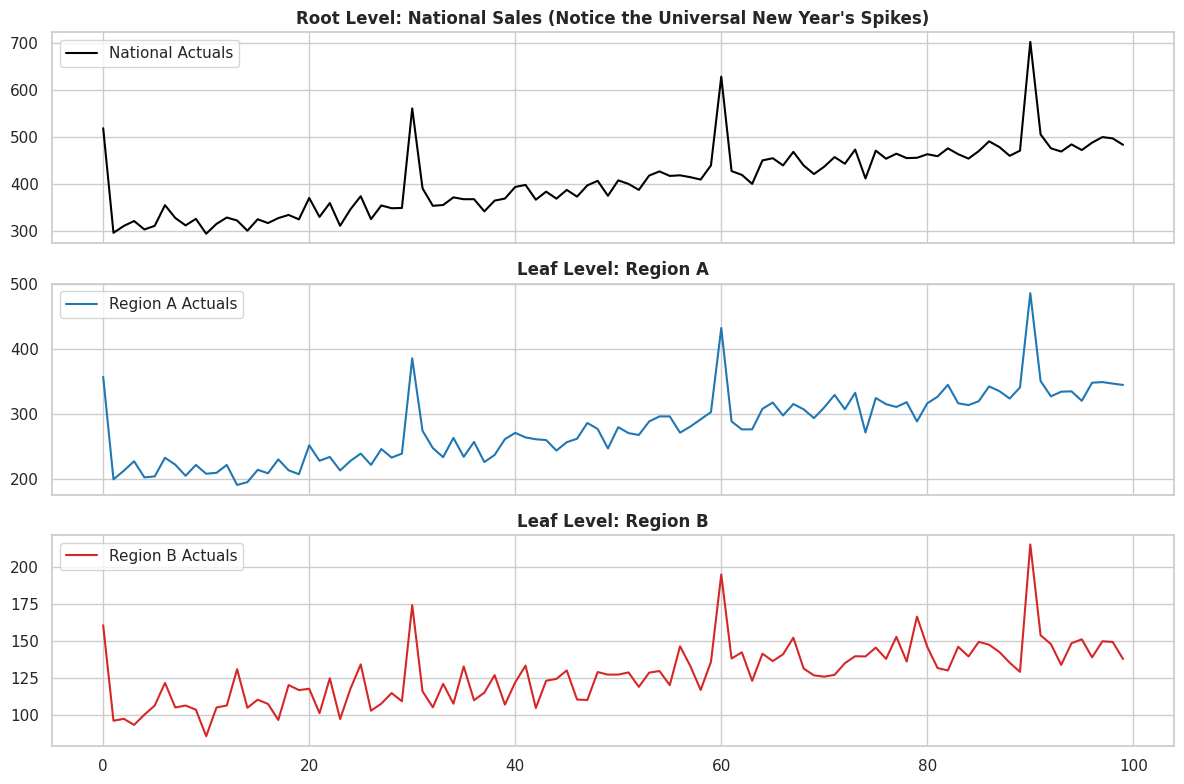

In [4]:
# 1. Simulate a 2-Level Hierarchy (100 days)
np.random.seed(42)
t = np.arange(100)

# Create a New Year's Day spike feature (Day 1, Day 31, Day 61, etc. for simulation)
new_years_flags = np.where(t % 30 == 0, 1, 0)
ny_spike = new_years_flags * 150 

# Base Signals
region_a_actual = 200 + (t * 1.5) + ny_spike + np.random.normal(0, 15, 100)
region_b_actual = 100 + (t * 0.5) + (ny_spike * 0.5) + np.random.normal(0, 10, 100)

# True Aggregation
national_actual = region_a_actual + region_b_actual

# 2. Simulate Independent 'Base Forecasts' for the next step (t=101, which is NOT New Year's)
# Assume our separate ML models produced these slightly flawed predictions:
pred_base_a = 355.0
pred_base_b = 145.0
pred_base_national = 515.0

print("--- 🚨 THE AGGREGATION PARADOX 🚨 ---")
print(f"Base National Forecast:    {pred_base_national}")
print(f"Sum of Base Regional (A+B): {pred_base_a + pred_base_b}")
print(f"Discrepancy (Error):        {pred_base_national - (pred_base_a + pred_base_b)}\n")

# 3. Apply Bottom-Up Reconciliation
reconciled_bu_national = pred_base_a + pred_base_b

# 4. Apply Top-Down Reconciliation (Based on historical average proportions)
prop_a = np.mean(region_a_actual / national_actual)
prop_b = np.mean(region_b_actual / national_actual)

reconciled_td_a = pred_base_national * prop_a
reconciled_td_b = pred_base_national * prop_b

# 5. Display the Reconciled Results
print("--- ✅ BOTTOM-UP RECONCILIATION ---")
print(f"National: {reconciled_bu_national:.1f}  |  Region A: {pred_base_a:.1f}  |  Region B: {pred_base_b:.1f}")

print("\n--- ✅ TOP-DOWN RECONCILIATION ---")
print(f"National: {pred_base_national:.1f}  |  Region A: {reconciled_td_a:.1f}  |  Region B: {reconciled_td_b:.1f}")

# 6. Matplotlib Visualization of the Hierarchy
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, national_actual, color='black', label='National Actuals')
axes[0].set_title("Root Level: National Sales (Notice the Universal New Year's Spikes)", fontweight='bold')
axes[0].legend(loc='upper left')

axes[1].plot(t, region_a_actual, color='#1f77b4', label='Region A Actuals')
axes[1].set_title("Leaf Level: Region A", fontweight='bold')
axes[1].legend(loc='upper left')

axes[2].plot(t, region_b_actual, color='#d62728', label='Region B Actuals')
axes[2].set_title("Leaf Level: Region B", fontweight='bold')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of Hierarchical Forecasting like **Writing a Corporate Budget**:

* **Base Forecasts (Anarchy)**: The CEO says the company needs $\$10$ Million in total budget. The Marketing VP calculates they need $\$6$ Million. The Engineering VP calculates they need $\$5$ Million. $6 + 5 = 11$. The math is broken.
* **Bottom-Up**: The CEO surrenders. They just add the VP's requests together and declare the total budget is now $\$11$ Million. The lower levels dictate the top.
* **Top-Down**: The CEO is a dictator. They lock the total budget at $\$10$ Million. They look at last year (Marketing used $60\%$, Engineering used $40\%$). They force Marketing to take $\$6$M and Engineering to take $\$4$M, regardless of what the VPs actually requested.
* **MinT Optimal Reconciliation**: The CEO puts the Base Forecasts into a statistical matrix. It realizes Marketing's $\$6$M request has high variance (they often ask for too much), but Engineering's $\$5$M request is historically highly accurate. The math adjusts the CEO's total slightly up to $\$10.2$M, gives Engineering $\$4.9$M, and Marketing $\$5.3$M, finding the perfect compromise that minimizes total error across the entire corporate structure.